In [1]:
import os
import time
import copy

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 5070 Laptop GPU


In [2]:
DATA_DIR = "./EuroSAT_RGB" 

print("Classes found:", os.listdir(DATA_DIR))

Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
IMG_SIZE = 64  

NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

transform_no_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

In [ ]:
full_dataset_no_aug = datasets.ImageFolder(root=DATA_DIR, transform=transform_no_aug)
full_dataset_aug = datasets.ImageFolder(root=DATA_DIR, transform=transform_aug)

CLASS_NAMES = full_dataset_no_aug.classes
print("Class-to-index mapping:", full_dataset_no_aug.class_to_idx)

total_size = len(full_dataset_no_aug)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size
print(f"Total: {total_size} | Train: {train_size} | Val: {val_size} | Test: {test_size}")

train_idx_ds, val_idx_ds, test_idx_ds = random_split(
    full_dataset_no_aug, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)
train_aug_ds, val_aug_ds, test_aug_ds = random_split(
    full_dataset_aug, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)


Loading dataset (no augmentation)...
Done. 27000 images found.
Loading dataset (with augmentation)...
Done. 27000 images found.
Class-to-index mapping: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}
Total images: 27000
Train: 18900 | Val: 4050 | Test: 4050
Split complete.


In [5]:
BATCH_SIZE = 64

train_loader_no_aug = DataLoader(train_idx_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_no_aug   = DataLoader(val_idx_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_no_aug  = DataLoader(test_idx_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

train_loader_aug = DataLoader(train_aug_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_aug   = DataLoader(val_aug_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_aug  = DataLoader(test_aug_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("DataLoaders ready.")
print(f"Batches per epoch (train): {len(train_loader_no_aug)}")

DataLoaders ready.
Batches per epoch (train): 296


In [ ]:
class TinyVGG(nn.Module):
   
    def __init__(self, input_channels=3, hidden_units=32, num_classes=10):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(input_channels, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units * 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units * 2, hidden_units * 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2), 
        )

        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(hidden_units * 2, hidden_units * 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units * 4, hidden_units * 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2), 
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 4 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        x = self.classifier(x)
        return x


model_scratch_test = TinyVGG().to(device)
dummy_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
output = model_scratch_test(dummy_input)
print("Output shape:", output.shape) 
del model_scratch_test, dummy_input, output
torch.cuda.empty_cache()

Output shape: torch.Size([2, 10])


In [ ]:
def build_resnet18_transfer(num_classes=10):

    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False

    return model.to(device)


model_transfer_test = build_resnet18_transfer()
dummy_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
output = model_transfer_test(dummy_input)
print("Output shape:", output.shape) 
del model_transfer_test, dummy_input, output
torch.cuda.empty_cache()

1.1%

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\kevin/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Output shape: torch.Size([2, 10])


In [ ]:
def train_model(model, train_loader, val_loader, num_epochs=10, lr=0.001, model_name="model"):
   
    criterion = nn.CrossEntropyLoss()
   
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        start_time = time.time()

        model.train()
        running_loss, running_correct, total_samples = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_correct += torch.sum(preds == labels).item()
            total_samples += images.size(0)

        train_loss = running_loss / total_samples
        train_acc = running_correct / total_samples

       
        model.eval()
        val_running_loss, val_running_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_running_correct += torch.sum(preds == labels).item()
                val_total += images.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_running_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

      
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start_time
        print(f"[{model_name}] Epoch {epoch+1}/{num_epochs} "
              f"| train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
              f"| {elapsed:.1f}s")

    model.load_state_dict(best_model_weights)
    print(f"[{model_name}] Best val accuracy: {best_val_acc:.4f}")
    return model, history

In [ ]:
NUM_EPOCHS = 10 
results = {}  

print("=" * 60)
print("Training: TinyVGG (scratch) - NO augmentation")
print("=" * 60)
model_scratch_noaug = TinyVGG().to(device)
model_scratch_noaug, hist_scratch_noaug = train_model(
    model_scratch_noaug, train_loader_no_aug, val_loader_no_aug,
    num_epochs=NUM_EPOCHS, model_name="scratch_noaug"
)
results["scratch_noaug"] = (model_scratch_noaug, hist_scratch_noaug)

print("=" * 60)
print("Training: TinyVGG (scratch) - WITH augmentation")
print("=" * 60)
model_scratch_aug = TinyVGG().to(device)
model_scratch_aug, hist_scratch_aug = train_model(
    model_scratch_aug, train_loader_aug, val_loader_aug,
    num_epochs=NUM_EPOCHS, model_name="scratch_aug"
)
results["scratch_aug"] = (model_scratch_aug, hist_scratch_aug)

print("=" * 60)
print("Training: ResNet18 (transfer) - NO augmentation")
print("=" * 60)
model_transfer_noaug = build_resnet18_transfer()
model_transfer_noaug, hist_transfer_noaug = train_model(
    model_transfer_noaug, train_loader_no_aug, val_loader_no_aug,
    num_epochs=NUM_EPOCHS, model_name="transfer_noaug"
)
results["transfer_noaug"] = (model_transfer_noaug, hist_transfer_noaug)

print("=" * 60)
print("Training: ResNet18 (transfer) - WITH augmentation")
print("=" * 60)
model_transfer_aug = build_resnet18_transfer()
model_transfer_aug, hist_transfer_aug = train_model(
    model_transfer_aug, train_loader_aug, val_loader_aug,
    num_epochs=NUM_EPOCHS, model_name="transfer_aug"
)
results["transfer_aug"] = (model_transfer_aug, hist_transfer_aug)

print("\nAll 4 training runs complete.")

Training: TinyVGG (scratch) - NO augmentation
[scratch_noaug] Epoch 1/10 | train_loss=1.4065 train_acc=0.4543 | val_loss=0.9243 val_acc=0.6588 | 26.2s
[scratch_noaug] Epoch 2/10 | train_loss=0.7991 train_acc=0.7170 | val_loss=0.7027 val_acc=0.7464 | 24.5s
[scratch_noaug] Epoch 3/10 | train_loss=0.5968 train_acc=0.7867 | val_loss=0.6280 val_acc=0.7770 | 24.0s
[scratch_noaug] Epoch 4/10 | train_loss=0.4782 train_acc=0.8337 | val_loss=0.4052 val_acc=0.8528 | 25.3s
[scratch_noaug] Epoch 5/10 | train_loss=0.3758 train_acc=0.8731 | val_loss=0.3687 val_acc=0.8716 | 25.6s
[scratch_noaug] Epoch 6/10 | train_loss=0.3172 train_acc=0.8911 | val_loss=0.3797 val_acc=0.8696 | 25.5s
[scratch_noaug] Epoch 7/10 | train_loss=0.2859 train_acc=0.9054 | val_loss=0.2975 val_acc=0.8923 | 23.9s
[scratch_noaug] Epoch 8/10 | train_loss=0.2424 train_acc=0.9171 | val_loss=0.2688 val_acc=0.9136 | 24.0s
[scratch_noaug] Epoch 9/10 | train_loss=0.2029 train_acc=0.9313 | val_loss=0.2893 val_acc=0.9136 | 23.8s
[scratch_

In [ ]:
def evaluate_on_test(model, test_loader):
   
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return all_preds, all_labels, acc


test_results = {}

test_results["scratch_noaug"] = evaluate_on_test(model_scratch_noaug, test_loader_no_aug)
test_results["scratch_aug"] = evaluate_on_test(model_scratch_aug, test_loader_aug)
test_results["transfer_noaug"] = evaluate_on_test(model_transfer_noaug, test_loader_no_aug)
test_results["transfer_aug"] = evaluate_on_test(model_transfer_aug, test_loader_aug)

for name, (preds, labels, acc) in test_results.items():
    print(f"{name}: Test accuracy = {acc:.4f}")

scratch_noaug: Test accuracy = 0.9141
scratch_aug: Test accuracy = 0.9081
transfer_noaug: Test accuracy = 0.8654
transfer_aug: Test accuracy = 0.8180


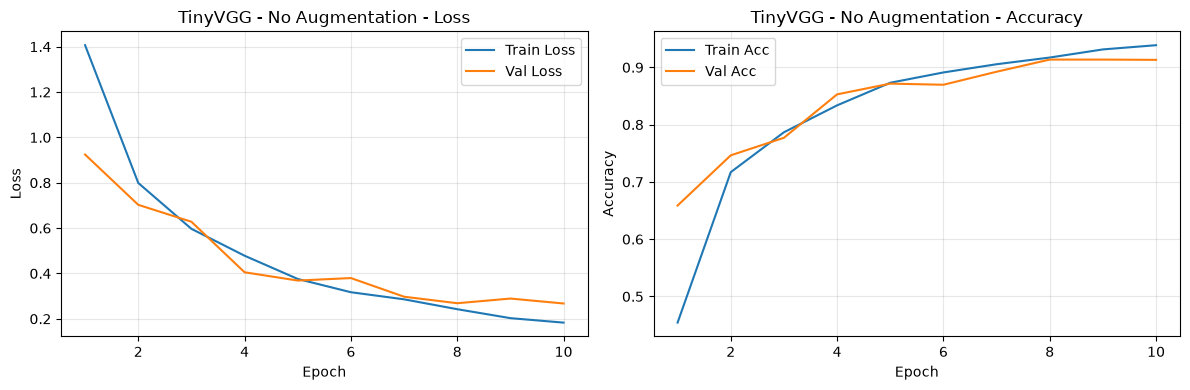

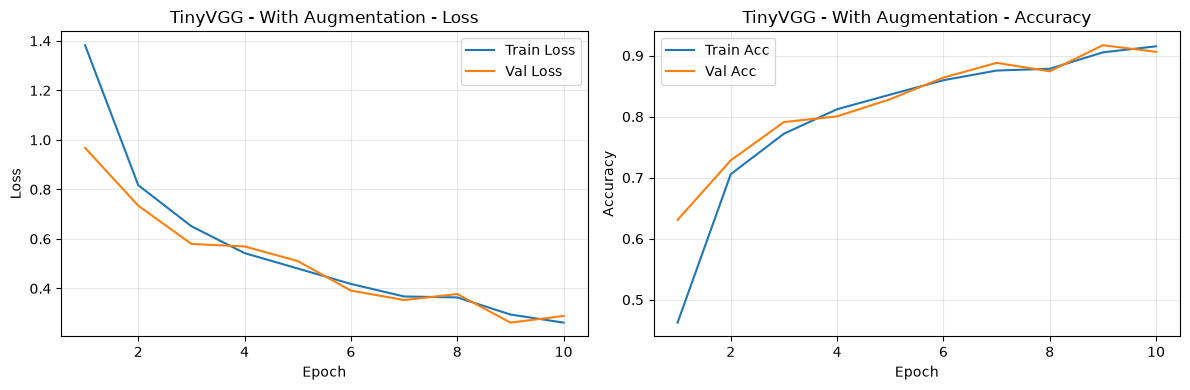

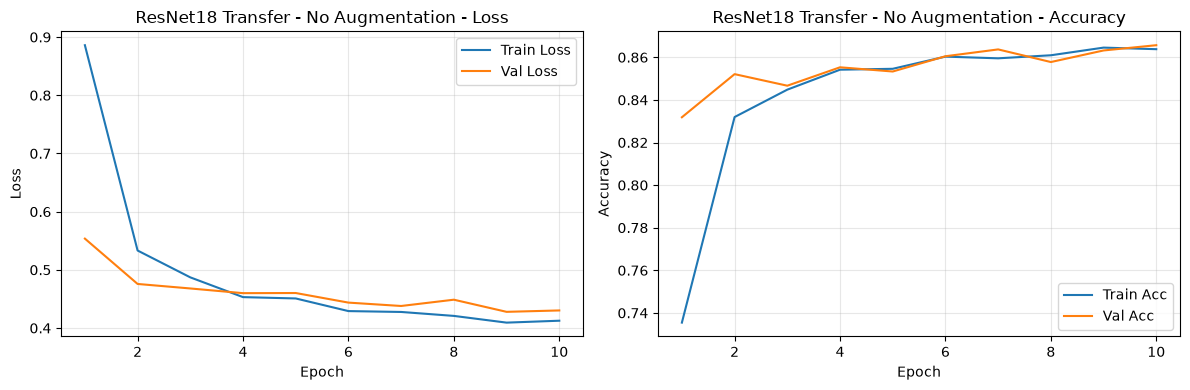

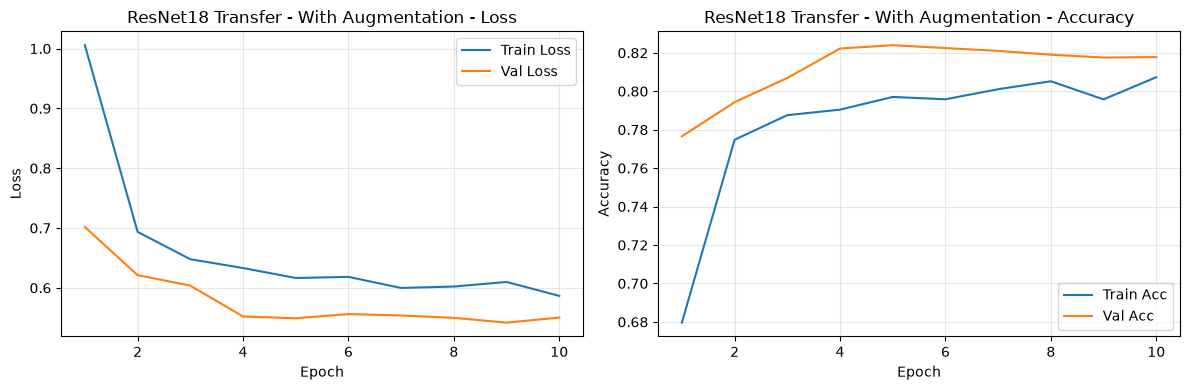

In [ ]:
def plot_history(history, title):
    
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs, history["val_acc"], label="Val Acc")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_history(hist_scratch_noaug, "TinyVGG - No Augmentation")
plot_history(hist_scratch_aug, "TinyVGG - With Augmentation")
plot_history(hist_transfer_noaug, "ResNet18 Transfer - No Augmentation")
plot_history(hist_transfer_aug, "ResNet18 Transfer - With Augmentation")

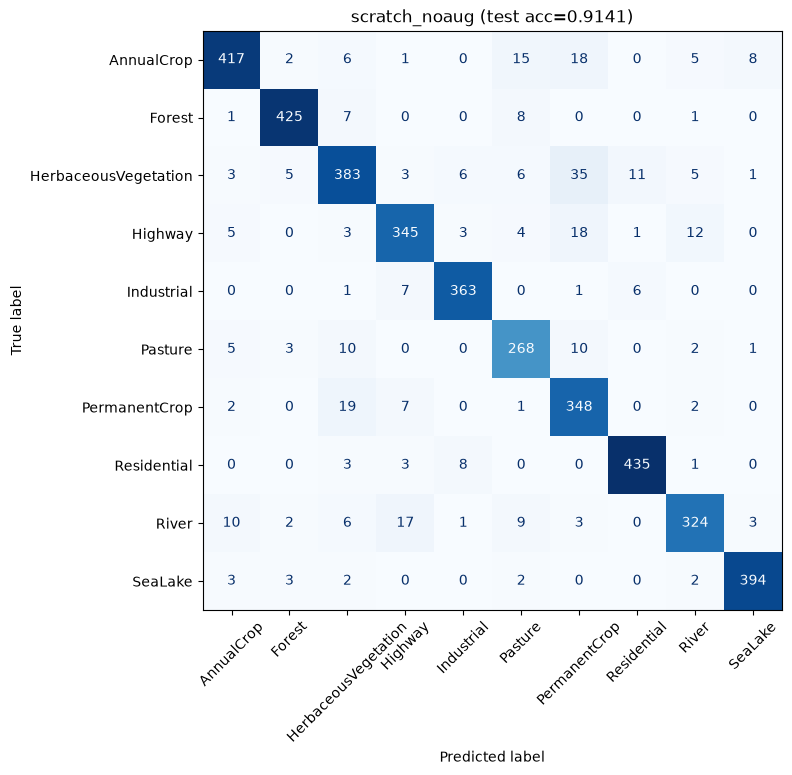

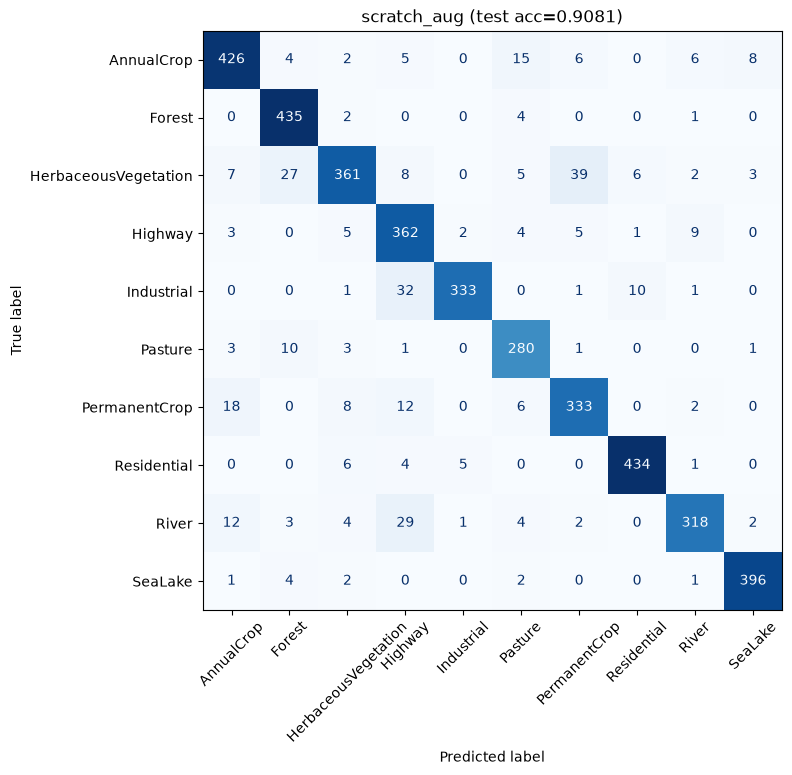

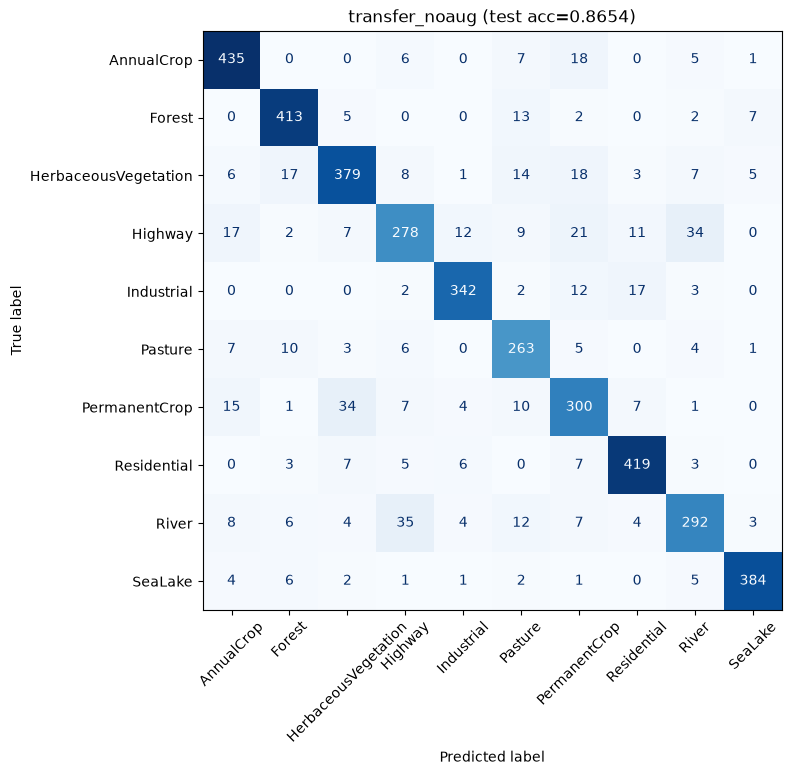

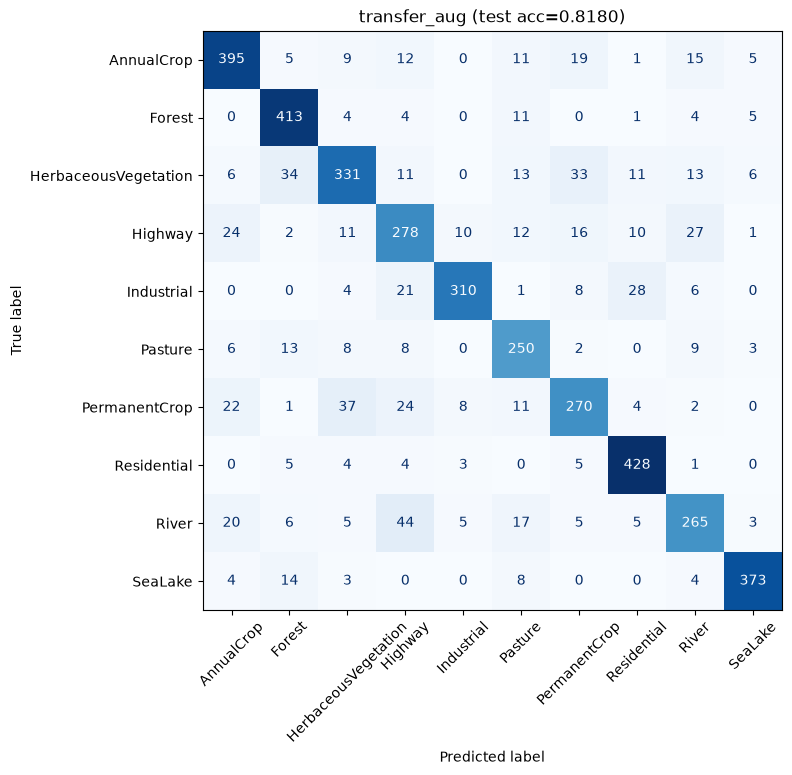

In [ ]:
def plot_confusion(preds, labels, title, class_names):
   
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()



for name, (preds, labels, acc) in test_results.items():
    plot_confusion(preds, labels, f"{name} (test acc={acc:.4f})", CLASS_NAMES)

In [13]:
import pandas as pd

summary_rows = []
for name, (preds, labels, test_acc) in test_results.items():
    model_type, aug_status = name.rsplit("_", 1)
    hist = {
        "scratch_noaug": hist_scratch_noaug,
        "scratch_aug": hist_scratch_aug,
        "transfer_noaug": hist_transfer_noaug,
        "transfer_aug": hist_transfer_aug,
    }[name]

    summary_rows.append({
        "Model": "TinyVGG (scratch)" if model_type == "scratch" else "ResNet18 (transfer)",
        "Augmentation": "Yes" if aug_status == "aug" else "No",
        "Best Val Acc": f"{max(hist['val_acc']):.4f}",
        "Final Train Acc": f"{hist['train_acc'][-1]:.4f}",
        "Test Acc": f"{test_acc:.4f}",
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

              Model Augmentation Best Val Acc Final Train Acc Test Acc
  TinyVGG (scratch)           No       0.9136          0.9387   0.9141
  TinyVGG (scratch)          Yes       0.9170          0.9152   0.9081
ResNet18 (transfer)           No       0.8657          0.8638   0.8654
ResNet18 (transfer)          Yes       0.8240          0.8073   0.8180
